In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from PIL import Image
import imageio
import os
import cv2

# Segmentation by Thresholding

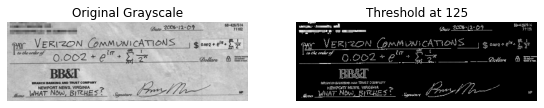

In [13]:
img = Image.open('Inputs/cropped_grayscale_check.jpg')
check_GS = np.array(img.convert('L')) 
check_GS_raw =np.array(img.convert('L')) 
flat_check_GS = check_GS.flatten()
# plt.imshow(check_GS, cmap='gray')

check_GS_hist, check_GS_bins = np.histogram(flat_check_GS, bins = 256) # if you want a proper histogram
# plt.stairs(check_GS_hist, check_GS_bins)

'''
Now we cut off pixels higher than 125 as a threshold in the grayscale image. Note that 
this technique works if the Region of Interest (ROI) is distinct from the background
when in grayscale. 
'''

threshold = 125


mask = check_GS > threshold
check_GS[mask] = 0

# fig, ax = plt.subplots(1, 2)

# ax[0].imshow(check_GS_raw, cmap='gray')
# ax[1].imshow(check_GS, cmap='gray')

# for i in range(2):
#     ax[i].axis('off')
    
# ax[0].set_title('Original Grayscale')
# ax[1].set_title('Threshold at 125')

# fig.set_size_inches(9.5, 4.5)
# fig.savefig('Results/Grayscale Segmentation Comparison.png',dpi=700)

# RGB to NCC Space

In [3]:
text = '''
args: arraylike image
out: r,g,b values in Normalized Chromaticity Space (NCC) 

you then build a scotter plot of r (x-axis) and g (y-axis) where
the location of b is implied since  r + g + b = 1

'''

def NCC(image):   # we convert from RGB space to NCC space (r,g, and an extra b)
    R = image[:,:,0]
    G = image[:,:,1]
    B = image[:,:,2]
    
    I = R + G + B
    
    # now we calculate histograms
    r = np.divide(R, I, out=np.zeros_like(R), where=I!=0)  # if division by zero, pass out 0
    g = np.divide(G, I, out=np.zeros_like(G), where=I!=0)  # we divide here R,G,B / I
    b = np.divide(B, I, out=np.zeros_like(B), where=I!=0)  # we only have 1 pixel with this error so yea

    return r, g, b


img_RGB = Image.open('Inputs/cuphead.png')
image_RGB = np.array(img_RGB.convert('RGB')) / 255
# plt.axis('off')
# plt.imshow(image_RGB)
# #====================================================================


R_RGB = image_RGB[:,:,0]    # we convert from RGB space to NCC space (r,g, and an extra b)
G_RGB = image_RGB[:,:,1]
B_RGB = image_RGB[:,:,2]

# fig, ax = plt.subplots(1,3)
# ax[0].imshow(R_RGB, cmap='Reds')
# ax[1].imshow(G_RGB, cmap='Blues')
# ax[2].imshow(B_RGB, cmap='Greens')
# for i in range(3):
#     ax[i].axis('off')
        
# fig.suptitle('RGB Channels of Cuphead and Mugman running')        
# fig.set_size_inches(13.5, 3.0, forward=False)
# fig.savefig('Results/Image RGB',dpi=1000)                  # RGB Channels of Image Separated                         
# #====================================================================

r_RGB = NCC(image_RGB)[0]
g_RGB = NCC(image_RGB)[1]
b_RGB = NCC(image_RGB)[2]


# plt.scatter(r_RGB,g_RGB,s= 0.05)   # this is the NCC in rg space
# plt.xlabel('Red')
# plt.ylabel('Green')
# plt.title('Normalized Chromaticity Coordinates of RGB Image')
# plt.savefig('Results/Image NCC', dpi=1000)                 # RGB Image in NCC space
# #====================================================================


img_roi = Image.open('Inputs/cuphead_roi.png')
image_roi = np.array(img_roi.convert('RGB')) / 255
# plt.imshow(image_roi)                                      # Region of Interest (ROI) 
# #====================================================================


r_roi = NCC(image_roi)[0]
g_roi = NCC(image_roi)[1]
b_roi = NCC(image_roi)[2]

# plt.scatter(r_roi,g_roi,s= 0.05)   # this is the NCC in rg space
# plt.xlim(0,1)
# plt.ylim(0,1)
# plt.xlabel('Red')
# plt.ylabel('Green')
# plt.title('Normalized Chromaticity Coordinates of ROI')
# plt.savefig('Results/ROI NCC', dpi=1000)                     # ROI in NCC space
# #====================================================================


text = '''
What we do then is to superimpose a Gaussian (in zhat) into the location of the ROI pixels in the 
NCC histogram. When we then take a pixel at the original histogram, we now have an
intensity value for it accdg to the Gaussian which was defined in NCC space. Hence, segmented! 
'''

# Parametric Segmentation

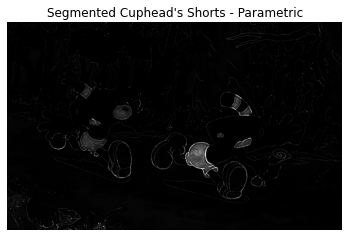

In [16]:
text = '''
args: RGB = arraylike, 3 dimensional array that represents and RGB image (uint8) 
      roi = arraylike, the image of ROI (uint8)

out: segmented image (arraylike, grayscale, uint8) 
'''


def parametric_segmentation(RGB, roi):
    r = NCC(RGB)[0]          # take pixel coordinates of RGB image in NCC space
    g = NCC(RGB)[1]
    b = NCC(RGB)[2]
    roi_mean = np.mean(roi)  # mean of roi
    roi_std = np.std(roi)    # std of roi
    # we now construct a Gaussian (z-hat) in RGB spaced centered at the ROI location in NCC space. 
    # the mean and std of the gaussian is dictated by the ROI 
    # helpful figure (not literally what's happening):
    # i deleted the link accidentally :< just look up a Gaussian in 3d space in Google Images
    
    gaussian_r = (1 / (roi_std*np.sqrt(np.pi))) * np.exp(-(r-roi_mean)**2 / 2*(roi_std**2))
    gaussian_g = (1 / (roi_std*np.sqrt(np.pi))) * np.exp(-(g-roi_mean)**2 / 2*(roi_std**2))
    
    segmented = gaussian_g*gaussian_r
    
    return segmented

segmented_parametric = parametric_segmentation(image_RGB, image_roi)
# plt.title("Segmented Cuphead's Shorts - Parametric")
# plt.axis('off')
# plt.imshow(segmented_parametric,cmap='gray_r')
# plt.imsave('Results/segmented_parametric.png', segmented_parametric, cmap='gray_r')

text = '''
There are artifacts in Mugman's blue pants because the game is watercolored. The
redness of the canvas seeps through, so there is a little bit of red in there. 

This method is highly dependent on the fit of the PDF function assumed. The Gaussian is good
but it can include unwanted colors with value near the ROI depending on the image (like in mine
where canvas information was included!)

TO DO: Make this into a subplots 
orig img, region of interest, segmented image
'''

# Non-Parametric Segmentation


In [5]:
text = ''' 
args: RGB = arraylike, 3 dimensional array that represents and RGB image (uint8) 
      roi = arraylike, the image of ROI (uint8)
      bins = int, bins of storage matrix. Set to 32 if there is no input. A higher number of bins means
      that the lookup table can have more color values to choose from making the function less accurate. 

out:  segmented image = arraylike, grayscale of the segmented image, uint8


source of code: Nino Ramones, National Insitute of Physics (thank you onin for also explaining it
to me, always a g!)
'''



def nonparametric_segmentation(orig_img, roi_img, bins=32):
    
    r_orig = (NCC(orig_img)[0]*(bins-1)).astype(int)
    g_orig = (NCC(orig_img)[1]*(bins-1)).astype(int)    # convert r,g to int 
    r_roi = (NCC(roi_img)[0]*(bins-1)).astype(int)
    g_roi = (NCC(roi_img)[1]*(bins-1)).astype(int)      # convert r,g to int 
    
    # then bin to a matrix
    img_matrix, xbins, ybins = np.histogram2d(g_roi.flatten(), r_roi.flatten(), 
                                                    bins = bins, range = [[0, bins], [0, bins]])
    
    # iterate all rows and columns of segmented_img
    # array of zeros with same shape as roi_img - basis image
    segmented_img = np.zeros(NCC(orig_img)[0].shape)
    for i in range(NCC(orig_img)[0].shape[0]): 
        for j in range(NCC(orig_img)[0].shape[1]):
            segmented_img[i,j] = img_matrix[g_orig[i,j], r_orig[i,j]]
            
    return segmented_img

segmented_nonparametric = nonparametric_segmentation(image_RGB, image_roi)  # grayscale segmented

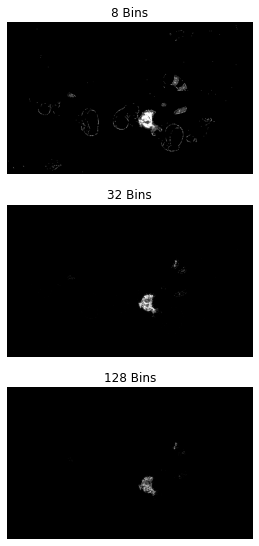

In [19]:
fig, ax = plt.subplots(3,1)
ax[0].imshow(nonparametric_segmentation(image_RGB, image_roi, bins=8), cmap='gray')
ax[1].imshow(nonparametric_segmentation(image_RGB, image_roi, bins=32), cmap='gray')
ax[2].imshow(nonparametric_segmentation(image_RGB, image_roi, bins=128), cmap='gray')

ax[0].set_title('8 Bins')
ax[1].set_title('32 Bins')
ax[2].set_title('128 Bins')

for i in range(3):
    ax[i].axis('off')

fig.set_size_inches(4.5, 9.5)
fig.savefig('Results/Non-Parametric Bin Size Comparison.png',dpi=700)
    

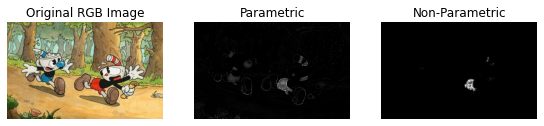

In [14]:
parametric_R = image_RGB[:,:,0]*segmented_parametric
parametric_G = image_RGB[:,:,1]*segmented_parametric
parametric_B = image_RGB[:,:,2]*segmented_parametric
parametric_RGB = np.dstack((parametric_R, parametric_G, parametric_B))
# plt.title("Segmented Cuphead's Shorts - Parametric")
# plt.axis('off')
# plt.imshow(parametric_RGB)

# =======================================================================
nonparametric_R = image_RGB[:,:,0]*segmented_nonparametric
nonparametric_G = image_RGB[:,:,1]*segmented_nonparametric
nonparametric_B = image_RGB[:,:,2]*segmented_nonparametric
nonparametric_RGB = np.dstack((nonparametric_R, nonparametric_G, nonparametric_B))
# plt.title("Segmented Cuphead's Shorts - Nonparametric")
# plt.axis('off')
# plt.imshow(nonparametric_RGB)


fig, ax = plt.subplots(1,3)
ax[0].imshow(image_RGB)
ax[1].imshow(segmented_parametric, cmap='gray_r')
ax[2].imshow(segmented_nonparametric, cmap='gray')

ax[0].set_title('Original RGB Image')
ax[1].set_title('Parametric')
ax[2].set_title('Non-Parametric')

for i in range(3):
    ax[i].axis('off')
    

fig.set_size_inches(9.5, 4.5)
fig.savefig('Results/Colored Segmentation Comparison.png',dpi=700)

